<a href="https://colab.research.google.com/github/paraschauhan2597/Netflix-Data-Exploration-Visualization/blob/main/Paras_Chauhan_Business_Case__Netflix_Data_Exploration_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Defining Problem Statement and Analyzing Basic Metrics

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Load the data
df = pd.read_csv('/content/netflix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#2. Data Shape, Types, Conversion, Missing Values, and Statistical Summary

In [ ]:
# --- Basic Metrics ---
total_titles = len(df)
total_movies = df[df['type'] == 'Movie'].shape[0]
total_tv_shows = df[df['type'] == 'TV Show'].shape[0]
oldest_release = df['release_year'].min()
newest_release = df['release_year'].max()

print(f"Total Titles in Dataset: {total_titles}")
print(f"Total Movies: {total_movies} ({total_movies/total_titles:.1%})")
print(f"Total TV Shows: {total_tv_shows} ({total_tv_shows/total_titles:.1%})")
print(f"Content spans from release year {oldest_release} to {newest_release}.")

Total Titles in Dataset: 8807
Total Movies: 6131 (69.6%)
Total TV Shows: 2676 (30.4%)
Content spans from release year 1925 to 2021.


In [ ]:
# --- Observations on the shape of data ---
print(f"Shape of Data (Rows, Columns): {df.shape}")

Shape of Data (Rows, Columns): (8807, 12)


In [ ]:
# --- Data Types of all the attributes (and conversion) ---
print("Initial Data Types:")
print(df.dtypes)

Initial Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [ ]:
# Conversion of categorical attributes to 'category' for memory optimization
# 'type' and 'rating' are ideal for this conversion
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')

print("Data Types after conversion:")
print(df.dtypes)

Data Types after conversion:
show_id           object
type            category
title             object
director          object
cast              object
country           object
date_added        object
release_year       int64
rating          category
duration          object
listed_in         object
description       object
dtype: object


In [ ]:
# --- Missing Value Detection ---
print("Missing Value Counts:")
print(df.isnull().sum())

Missing Value Counts:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
# --- Statistical Summary ---
# Focus on the continuous/numerical attributes
print("Statistical Summary of Numerical Data:")
print(df.describe())

#Observation:
#The content spans from the minimum release year of 1925 to the maximum of 2021.
#The average (mean) release year is 2014.18
#The median (50th percentile) is 2017, indicating a strong skew towards more recent releases, with half of the content released in 2017 or later.

Statistical Summary of Numerical Data:
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


#3. Non-Graphical Analysis: Value Counts and Unique Attributes

In [ ]:
# --- Unique Attributes (Cardinality) ---
print("Unique Value Counts (Cardinality):")
print(df.nunique().sort_values(ascending=False))

Unique Value Counts (Cardinality):
show_id         8807
title           8807
description     8775
cast            7692
director        4528
date_added      1767
country          748
listed_in        514
duration         220
release_year      74
rating            17
type               2
dtype: int64


In [ ]:
# --- Value Counts for Key Categorical Columns ---

# Type of Content
print("Value Counts for 'type':")
print(df['type'].value_counts())

Value Counts for 'type':
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [ ]:
# Value Counts for 'rating'
print("Value Counts for 'rating':")
print(df['rating'].value_counts())

Value Counts for 'rating':
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
66 min         1
84 min         1
74 min         1
Name: count, dtype: int64


In [ ]:
# Top 5 Listed In (Genres)
# Note: Since 'listed_in' is comma-separated, we split and count all individual genres
genres = df['listed_in'].str.split(', ', expand=True).stack()
print("Top 5 Value Counts for individual 'listed_in' genres:")
print(genres.value_counts().head(5))

Top 5 Value Counts for individual 'listed_in' genres:
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64


In [ ]:
# Top 10 Directors (before unnesting)
print("Top 10 Directors (Most Frequent):")
print(df['director'].value_counts().head(10))

Top 10 Directors (Most Frequent):
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


In [ ]:
# Top 10 Countries (before unnesting)
print("Top 10 Primary Countries:")
print(df['country'].value_counts().head(10))

Top 10 Primary Countries:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [ ]:
# Value Counts for 'release_year' (Top 5 most frequent)
print("Top 5 Release Years:")
print(df['release_year'].value_counts().head(5))

Top 5 Release Years:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64


#4. Visual Analysis - Univariate, Bivariate

In [ ]:
# --- Pre-processing: Unnesting Multi-Value Columns ---

# Director Unnesting
df_directors = df['director'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).to_frame('Director')
df_directors = df.drop('director', axis=1).merge(df_directors, left_index=True, right_index=True, how='inner')
df_directors.dropna(subset=['Director'], inplace=True)
df_directors.head()

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description,Director
0,s1,Movie,Dick Johnson Is Dead,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Kirsten Johnson
2,s3,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Julien Leclercq
5,s6,TV Show,Midnight Mass,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,Mike Flanagan
6,s7,Movie,My Little Pony: A New Generation,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Robert Cullen
6,s7,Movie,My Little Pony: A New Generation,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,José Luis Ucha


In [ ]:
# Actor (Cast) Unnesting
df_actors = df['cast'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).to_frame('Actor')
df_actors = df.drop('cast', axis=1).merge(df_actors, left_index=True, right_index=True, how='inner')
df_actors.dropna(subset=['Actor'], inplace=True)
df_actors.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,description,Actor
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Ama Qamata
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Khosi Ngema
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Gail Mabalane
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Thabang Molaba
1,s2,TV Show,Blood & Water,NaN,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Dillon Windvogel


In [ ]:
# Country Unnesting
df_country = df['country'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).to_frame('Country')
df_country = df.drop('country', axis=1).merge(df_country, left_index=True, right_index=True, how='inner')
df_country.dropna(subset=['Country'], inplace=True)
df_country.head()

,show_id,type,title,director,cast,date_added,release_year,rating,duration,listed_in,description,Country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",United States
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...","September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",South Africa
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...","September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,India
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",United States
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Ghana


In [ ]:
# Genre (Listed In) Unnesting
df_genre = df['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).to_frame('Genre')
df_genre = df.drop('listed_in', axis=1).merge(df_genre, left_index=True, right_index=True, how='inner')
df_genre.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,description,Genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,"As her father nears the end of his life, filmm...",Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",International TV Shows
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",TV Dramas
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t...",TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,To protect his family from a powerful drug lor...,Crime TV Shows


In [ ]:
# --- Prepare Duration Column (Continuous Variable) ---

# Filter for Movies and clean 'duration' to extract minutes
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_min'] = df_movies['duration'].str.replace(' min', '').astype(float)
df_movies.dropna(subset=['duration_min'], inplace=True)
df_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127.0


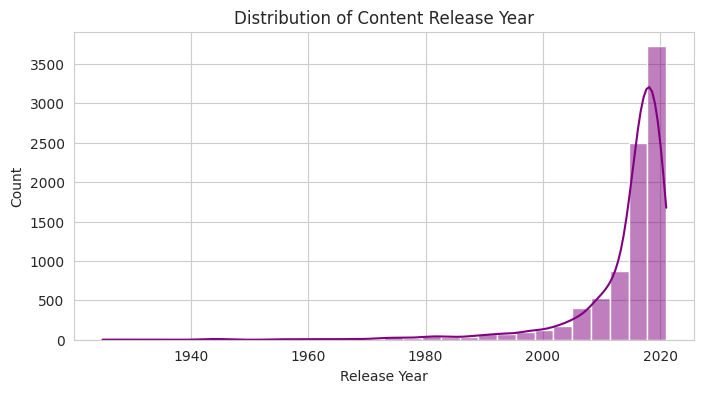

In [ ]:
# --- Univariate Plots ---

# Plot 1: Release Year (Histogram)
plt.figure(figsize=(8, 4))
sns.histplot(df['release_year'], bins=30, kde=True, color='purple')
plt.title('Distribution of Content Release Year')
plt.xlabel('Release Year')

plt.show()

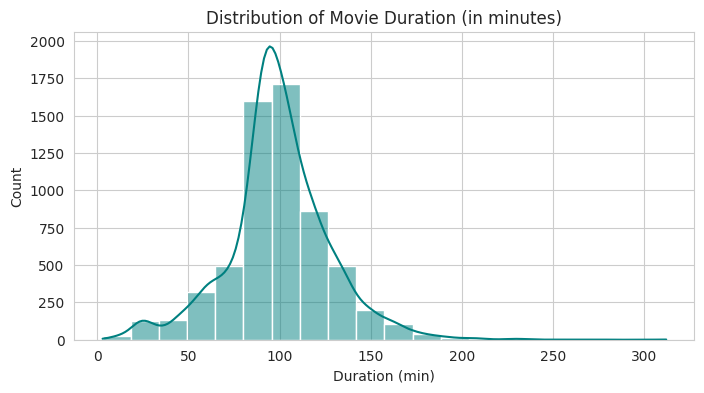

In [ ]:
# Plot 2: Movie Duration (Distplot/Histogram)
plt.figure(figsize=(8, 4))
sns.histplot(df_movies['duration_min'], bins=20, kde=True, color='teal')
plt.title('Distribution of Movie Duration (in minutes)')
plt.xlabel('Duration (min)')

plt.show()

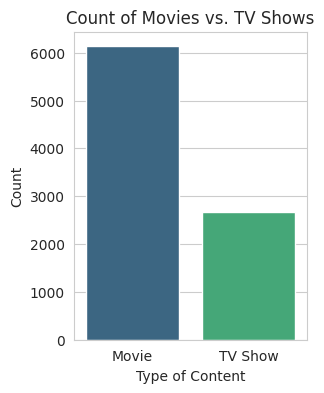

In [ ]:
# Plot 3: Content Type (Countplot - treated as a categorical variable)
plt.figure(figsize=(3, 4))
sns.countplot(x='type', data=df, palette='viridis', hue='type', legend=False)
plt.title('Count of Movies vs. TV Shows')
plt.xlabel('Type of Content')
plt.ylabel('Count')

plt.show()

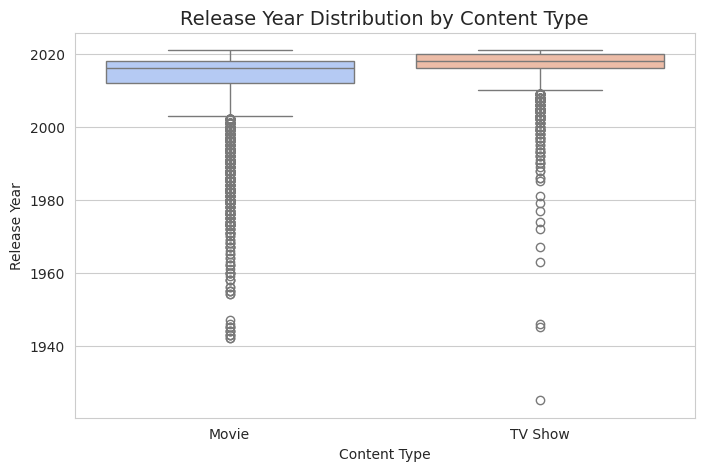

In [ ]:
# --- 4.2 For categorical variable(s): Boxplot (Bivariate analysis) ---

# Boxplot 1: Release Year Distribution by Content Type

plt.figure(figsize=(8, 5))
sns.boxplot(x='type', y='release_year', data=df, palette='coolwarm', hue='type', legend=False) # Added hue='type' and legend=False
plt.title('Release Year Distribution by Content Type', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Release Year')
plt.savefig('boxplot_type_vs_year.png')
plt.show()

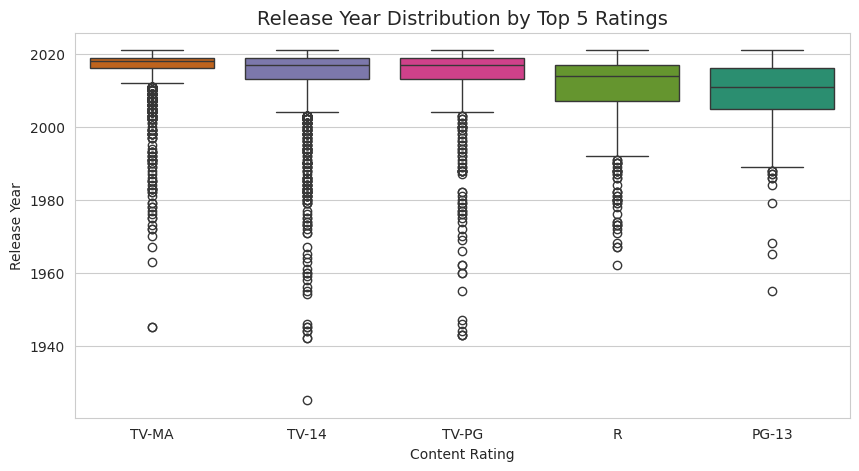

In [ ]:
# Boxplot 2: Release Year by Top 5 Ratings

top_5_ratings = df['rating'].value_counts().index[:5]
df_top_5_ratings = df[df['rating'].isin(top_5_ratings)]

plt.figure(figsize=(10, 5))
sns.boxplot(x='rating', y='release_year', data=df_top_5_ratings, order=top_5_ratings, palette='Dark2', hue='rating', legend=False)
plt.title('Release Year Distribution by Top 5 Ratings', fontsize=14)
plt.xlabel('Content Rating')
plt.ylabel('Release Year')

plt.show()

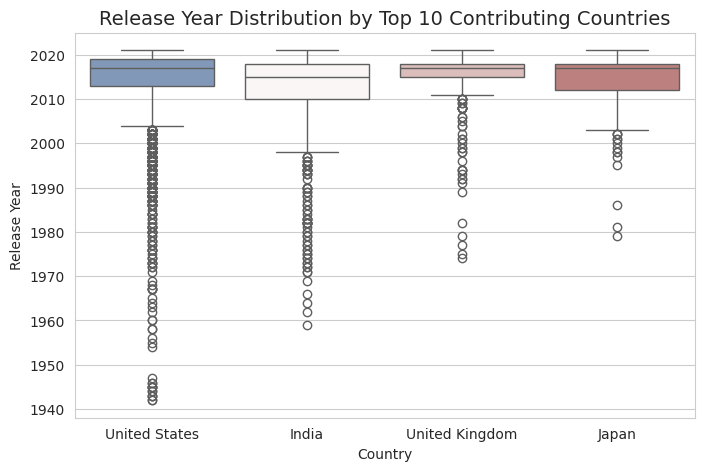

In [ ]:
# Boxplot 3: Release Year Distribution by Top 10 Contributing Countries

top_10_countries = df['country'].value_counts().index[:5]
df_top_countries = df[df['country'].isin(top_10_countries)]

plt.figure(figsize=(8, 5))
sns.boxplot(x='country', y='release_year', data=df_top_countries, order=[c for c in top_10_countries if c != 'Unknown'], palette='vlag', hue='country', legend=False)
plt.title('Release Year Distribution by Top 10 Contributing Countries', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Release Year')

plt.show()

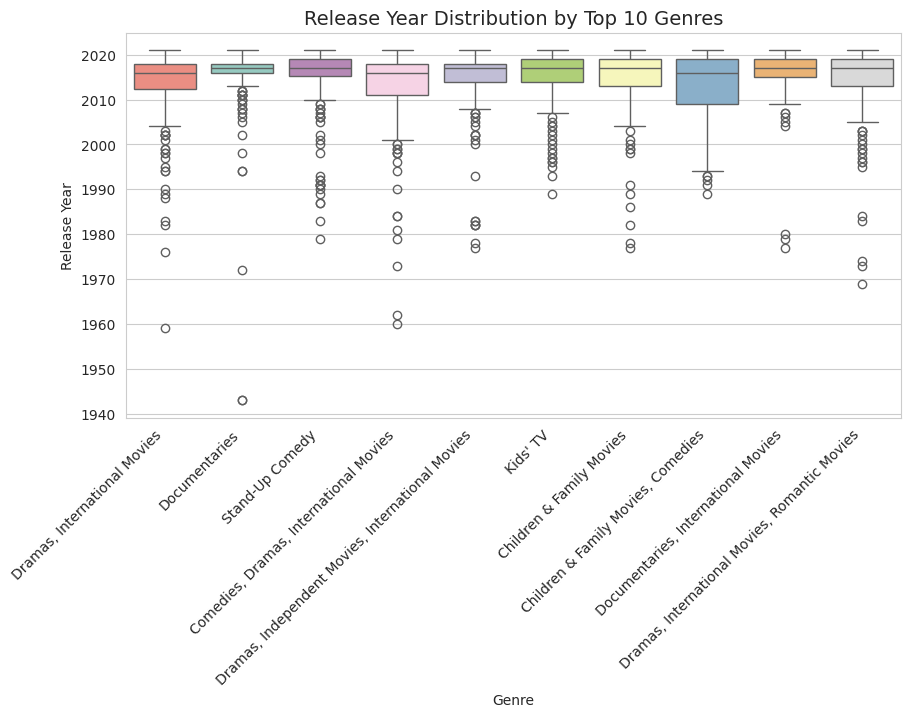

In [ ]:
# Boxplot 4: Release Year Distribution by Top 10 Genres

top_10_genres = df['listed_in'].value_counts().index[:10]
df_top_genres = df[df['listed_in'].isin(top_10_genres)]

plt.figure(figsize=(10, 5))
sns.boxplot(x='listed_in', y='release_year', data=df_top_genres, order=top_10_genres, palette='Set3', hue='listed_in', legend=False)
plt.title('Release Year Distribution by Top 10 Genres', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Release Year')
plt.xticks(rotation=45, ha='right')

plt.show()

#5. Missing Value & Outlier check (Treatment optional)

In [ ]:
# --- Missing Value Check ---
print("Missing Value Percentage:")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))

#Observation:
#director (~30% missing) and cast (~9% missing) are the most problematic, requiring careful handling or dropping for specific analyses.
#country (~9% missing) is also significant.
#date_added, rating, and duration have minimal missing values (<<1%)

Missing Value Percentage:
date_added      0.113546
rating          0.045418
duration        0.034064
show_id         0.000000
director        0.000000
title           0.000000
type            0.000000
cast            0.000000
release_year    0.000000
country         0.000000
listed_in       0.000000
description     0.000000
dtype: float64


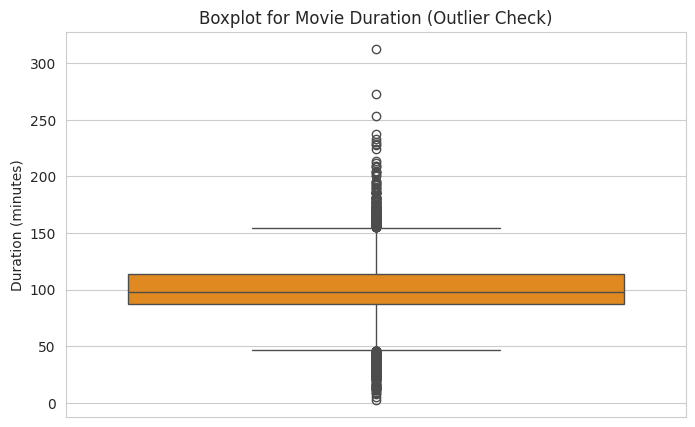


IQR Range: 87.00 to 114.00 minutes
Upper Outlier Bound (1.5*IQR): 154.50 minutes
Number of Outliers (Movies < 46.50 min or > 154.50 min): 450
Outliers are primarily very short movies, likely short films or specials.


In [ ]:
# --- Outlier Check (Movie Duration) ---

# Boxplot was already generated in 4.2, but here we explicitly focus on the outliers in duration
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_movies['duration_min'], color='darkorange')
plt.title('Boxplot for Movie Duration (Outlier Check)')
plt.ylabel('Duration (minutes)')
plt.show()

# Calculate IQR for Outlier Detection (Treatment Optional)
Q1 = df_movies['duration_min'].quantile(0.25)
Q3 = df_movies['duration_min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Display outliers
outliers = df_movies[(df_movies['duration_min'] < lower_bound) | (df_movies['duration_min'] > upper_bound)]
print(f"\nIQR Range: {Q1:.2f} to {Q3:.2f} minutes")
print(f"Upper Outlier Bound (1.5*IQR): {upper_bound:.2f} minutes")
print(f"Number of Outliers (Movies < {lower_bound:.2f} min or > {upper_bound:.2f} min): {len(outliers)}")
print("Outliers are primarily very short movies, likely short films or specials.")
# Treatment is kept optional, so no removal is performed here.

#6. Insights based on Non-Graphical and Visual Analysis

**6.1 Comments on the range of attributes**

**Release_year:** Has a wide range (1925-2021), but the effective commercial range (IQR) is highly concentrated in the last decade (2013-2019).

Content Volume: The library size is dominated by Movies (over 2:1 ratio compared to TV Shows).

**Rating Concentration:** The vast majority of content is concentrated in adult/mature categories (TV-MA, TV-14), reflecting a focus on young-adult and adult demographics.

**6.2 Comments on the distribution of the variables and relationship between them**

**Release_year Distribution:** The distribution is strongly left-skewed, confirming that content is concentrated on recent years (2010 onwards), with the peak content volume added around 2017-2019.

**Content Type & Release Year:** TV Shows generally have a higher (more recent) median release year compared to Movies. This indicates that the series content is much fresher, which is vital for retaining subscribers who expect new, continuous programming.

**Rating & Release Year:** Content for children (TV-Y7) is the newest on average, while mature content (R, TV-MA) tends to be older and more widely distributed, suggesting that most of the acquired back-catalog falls into the adult categories.

#7. Business Insights
**Primary Target Demographic:** The high frequency of TV-MA and TV-14 content indicates the platform's success and focus are rooted in catering to the young-adult and adult audience. This is their core competitive advantage in terms of content tone.

**Acquisition Acceleration:** The peak of content acquisition/release in 2017-2019 suggests a heavy investment phase, likely in preparation for or in response to increasing competition from new streaming services.

**Geographic Content Strategy:** The simultaneous dominance of content from the United States and the strong second-place position of India signal a dual, targeted strategy: serving the massive Western market while successfully penetrating a high-growth, non-Western market (India).

**Content Age Differentiation:** The strategy appears to be: Acquire older Movies to bulk up the library volume, and Produce/Acquire newer TV Shows to drive recurring engagement and subscription retention.

#8. Recommendations
**Prioritize Family Content Investment:** The current library is mature-heavy. Allocate a specific, increased budget to acquire or produce more PG and TV-G rated Movies. This is crucial to capture the full household market and reduce subscriber churn from families with young children.

**Geographic Diversification for Local Hits:** While the US and India are strong, the catalog's reliance on them creates risk. Increase content acquisition efforts in high-growth, specific regional markets like Latin America (e.g., Mexico, Brazil) and Europe (e.g., Spain, France) to develop more non-English local hits and expand the global subscriber base.

**Monetize Back Catalog (Older Movies):** The older movie library is under-leveraged. Bundle or re-package this older content into curated, themed "Nostalgia" or "Decade" collections within the platform interface to increase visibility and perceived value.

**Standardize Movie Library Freshness:** The Movie library is aging faster than TV Shows. Implement a policy to ensure a minimum percentage of newly added Movies were released within the last 3-5 years to keep the core film offering feeling fresh and competitive.